# 0. Load Data

## 0.1 Load Data

In [ ]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
logging.basicConfig(level=logging.INFO)

# variables
# run_dir = os.path.join("..", "outputs", "run-25-05-01-01")  # doid - no controls
# run_dir = os.path.join("..", "outputs", "run-25-05-07-01")  # doid - grouped diseases
run_dir = os.path.join("..", "outputs", "run-25-07-08-07")  # doid - grouped diseases - ECS
# run_dir = os.path.join("..", "outputs", "run-25-07-09-05")  # doid - grouped diseases - DAB
# run_dir = os.path.join("..", "outputs", "run-25-05-07-02")  # doid - control + dataset
run_dir = os.path.join("..","outputs","run-25-07-24-02")
run_dir = os.path.join("..","outputs","run-25-07-26-01")
run_dir = os.path.join("..","outputs","run-25-08-04-08") # doid - grouped multilabel lvl1
run_dir = os.path.join("..","outputs","run-25-08-05-01") # doid - grouped multilabel bot 50
run_dir = os.path.join("..","..","outputs","run-25-08-08-02") # doid - grouped multilabel CLS
run_dir = os.path.join("..","..","outputs","run-25-08-08-03") # doid - grouped multilabel CLS_MULTILABEL
output_dir = os.path.join(run_dir, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions


def load_run_output(input_dir: str) -> tuple:
    """Load the output of a run
    Args:
        input_dir (str): path to the run output directory
    Returns:
        loaded_variables (tuple): tuple of loaded variables
    """

    variables_to_load = [
        # "split",
        "predictions_test",
        "labels_test",
        "results_test",
        "all_outputs_test",
        "predictions_valid",
        "labels_valid",
        "results_valid",
        "all_outputs_valid",
        "predictions_train",
        "labels_train",
        "results_train",
        "all_outputs_train",
        "adata_orig",
        "id2type",
        "train_indices",
        "valid_indices",
    ]

    # initialize loaded variables as an empty tuple
    loaded_variables = ()

    # loop through variables
    for variable in variables_to_load:
        if variable.startswith("adata_"):
            if False:
                # load everything
                loaded_variable = ad.read_h5ad(
                    os.path.join(input_dir, f"{variable}.h5ad")
                )

            else:
                # do not load everything
                loaded_variable = ad.read_h5ad(
                    os.path.join(input_dir, f"{variable}.h5ad"), backed="r"
                )

        else:
            with open(os.path.join(input_dir, f"{variable}.pkl"), "rb") as f:
                loaded_variable = pickle.load(f)

        # add the loaded variable to the tuple
        loaded_variables += (loaded_variable,)

    print(f"Nº of loaded variables {len(loaded_variables)}")

    return loaded_variables


# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-05-07-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: random
n_splits: 3
n_tested_splits: 3
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do


In [61]:
import importlib

importlib.reload(ut)
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

## Quality Control

In [67]:
epoch_loss = pickle.load(open("/aloy/home/ddalton/projects/scGPT_playground/outputs/run-25-08-08-03/metrics_epochs.pkl", "rb"))

In [76]:
epoch_loss["epoch_2"].keys()

dict_keys(['train_loss', 'valid_loss', 'train_acc', 'valid_acc', 'train_err', 'valid_err', 'test_err'])

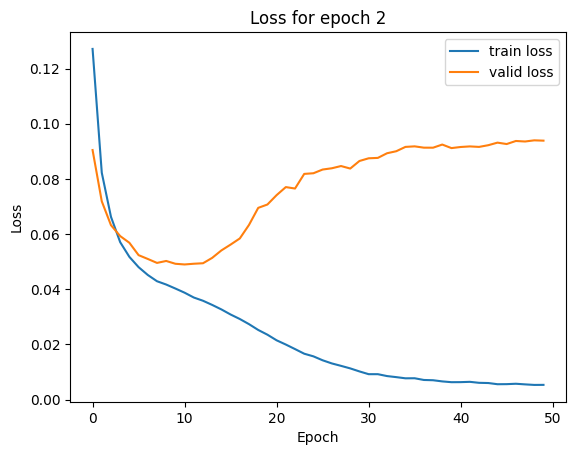

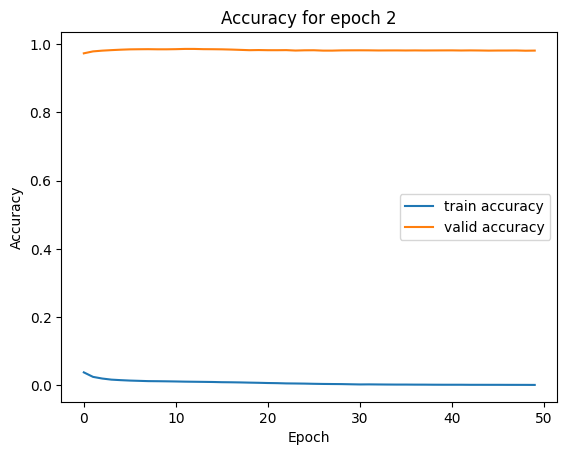

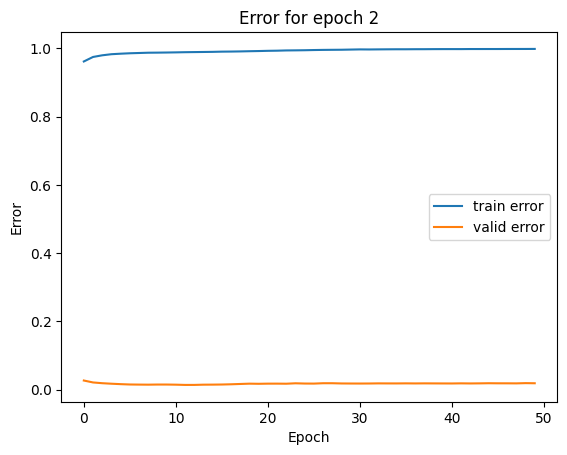

In [81]:
def plot_loss(epoch_loss: dict, epoch: int = 2):
    t_loss = epoch_loss[f"epoch_{epoch}"]["train_loss"]
    v_loss = epoch_loss[f"epoch_{epoch}"]["valid_loss"]
    plt.plot(t_loss, label="train loss")
    plt.plot(v_loss, label="valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss for epoch {epoch}")
    plt.legend()
    plt.show()

plot_loss(epoch_loss, epoch=2)


def plot_accuracy(epoch_loss: dict, epoch: int = 2):
    t_acc = epoch_loss[f"epoch_{epoch}"]["train_acc"]
    v_acc = epoch_loss[f"epoch_{epoch}"]["valid_acc"]
    plt.plot(t_acc, label="train accuracy")
    plt.plot(v_acc, label="valid accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy for epoch {epoch}")
    plt.legend()
    plt.show()

plot_accuracy(epoch_loss, epoch=2)


def plto_err(epoch_loss: dict, epoch: int = 2):
    t_err = epoch_loss[f"epoch_{epoch}"]["train_err"]
    v_err = epoch_loss[f"epoch_{epoch}"]["valid_err"]
    plt.plot(t_err, label="train error")
    plt.plot(v_err, label="valid error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title(f"Error for epoch {epoch}")
    plt.legend()
    plt.show()
    
plto_err(epoch_loss, epoch=2)

In [10]:
data = list()

for i in range(0, len(results_test)):
    data.append(
        {
            "accuracy": results_test[i]["test/accuracy"],
            "precision": results_test[i]["test/precision"],
            "recall": results_test[i]["test/recall"],
            "macro_f1": results_test[i]["test/macro_f1"],
            "type": "test",
        }
    )
    data.append(
        {
            "accuracy": results_valid[i]["test/accuracy"],
            "precision": results_valid[i]["test/precision"],
            "recall": results_valid[i]["test/recall"],
            "macro_f1": results_valid[i]["test/macro_f1"],
            "type": "validation",
        }
    )
    data.append(
        {
            "accuracy": results_train[i]["test/accuracy"],
            "precision": results_train[i]["test/precision"],
            "recall": results_train[i]["test/recall"],
            "macro_f1": results_train[i]["test/macro_f1"],
            "type": "train",
        }
    )

df_performance = pd.DataFrame(data)

if len(results_test) == 1:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = df_grouped_mean.astype(str)

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = df_grouped_mean.round(3).astype(str)


else:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = (
        df_grouped_mean.astype(str) + " ± " + df_grouped_std.astype(str)
    )

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = (
        df_grouped_mean.round(3).astype(str) + " ± " + df_grouped_std.round(3).astype(str)
    )




df_performance_summary

,accuracy,precision,recall,macro_f1
type,,,,
test,0.436,0.391,0.277,0.308
train,0.804,0.985,0.77,0.859
validation,0.76,0.94,0.719,0.804


<Axes: ylabel='macro_f1'>

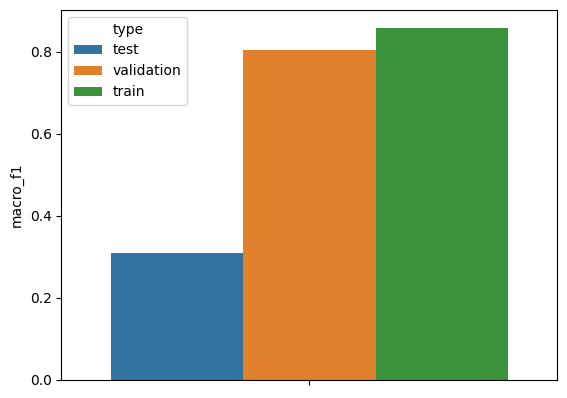

In [11]:
sns.barplot(data=df_performance, hue="type", y="macro_f1")



# 1. Load Data

## 1.1 Load scGPT Embeddings

In [ ]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable
split_idx = 0

# functions


In [ ]:
# 2. Load Data
# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)

# load scGPT embeddings
embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])



# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

In [20]:
adata_train.obs["dataset"].nunique()

574

## 1.2 Load DO pairs

In [26]:
"""1.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["do_id_study"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (15576, 8)
Nº of significant pairs in dataset (top 5% IC): (1138, 8)
Nº of significant pairs in dataset (top 1% IC): (330, 8)
Nº of negative pairs in dataset (outside 5%): (14438, 8)


# 2. Benchmark Disease vs Control Similarity

In [ ]:
"""2. Benchmark Disease vs Control Similarity

Structure:
    1. Imports, Variables, Functions
    2. Get Similarity
    3. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
from tqdm import tqdm
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# variables


# functions
# 2. Get Similarity
(c_same_same, w_same_same), (c_same_diff, w_same_diff) = vz.get_same_disease_sim(adata_train.obs, c_matrix_train)

# get unrelated pairs
c_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=1000,
    seed=42,
)



In [ ]:
# 3. Plot Similarity
# weighted
vz.plot_kde([c_same_same, c_same_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Unrelated"], 
            title="Same Disease Cosine Similarity", 
            colors=["#08519c","#6baed6", "gray"],
             weights=[w_same_same, w_same_diff, None])

# unweighted
vz.plot_kde([c_same_same, c_same_diff, c_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Unrelated"], 
            title="Same Disease Cosine Similarity", 
            colors=["#08519c","#6baed6", "gray"],
             weights=None)

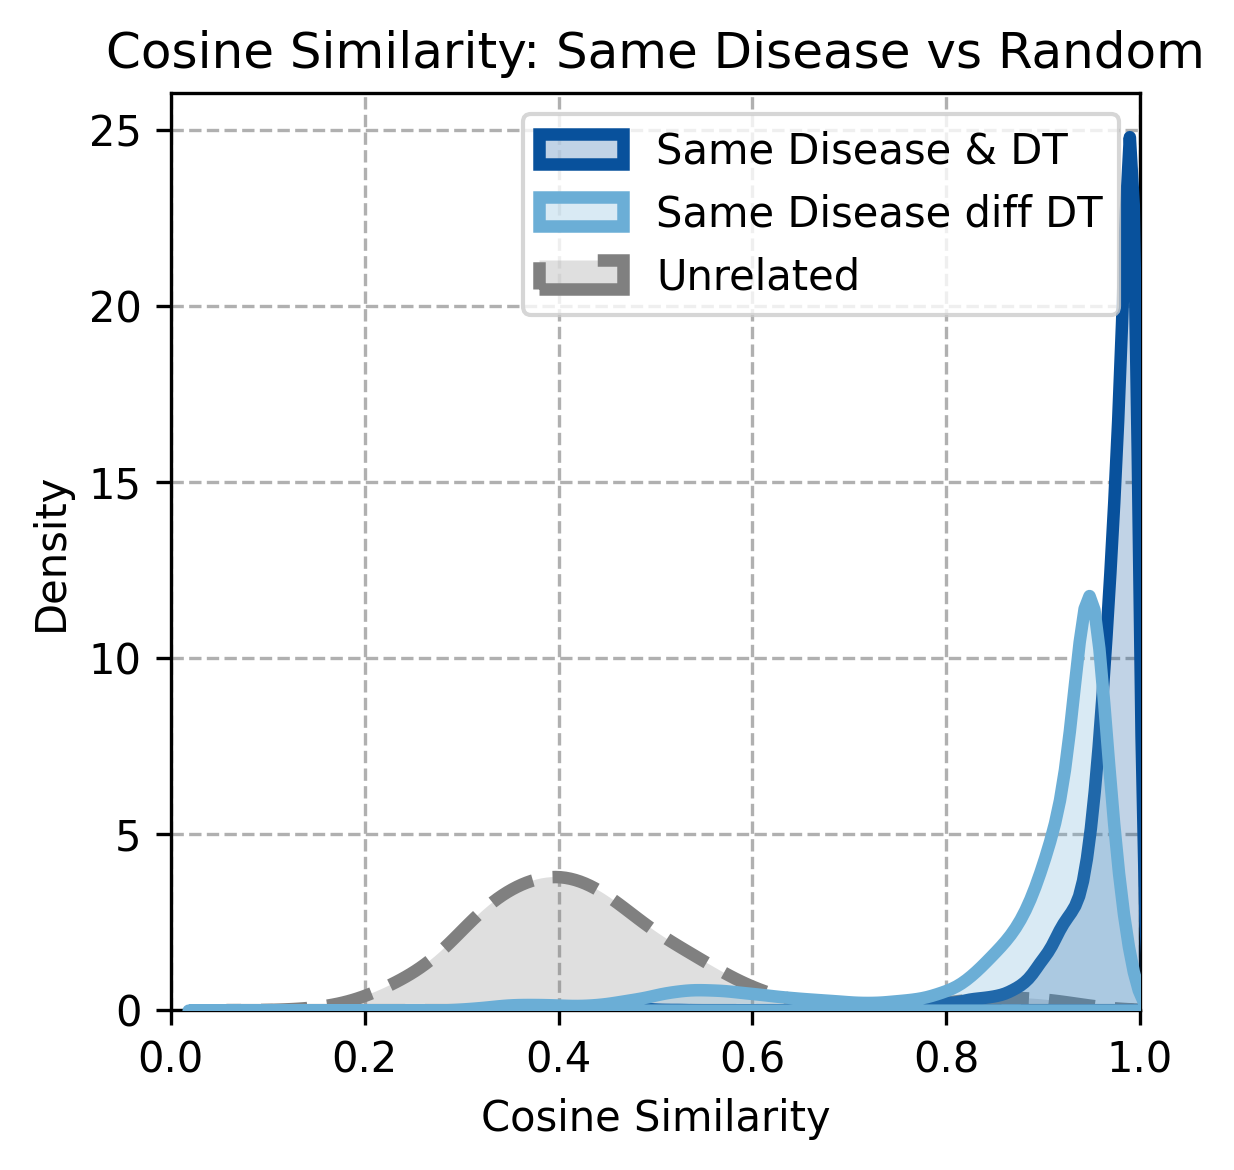

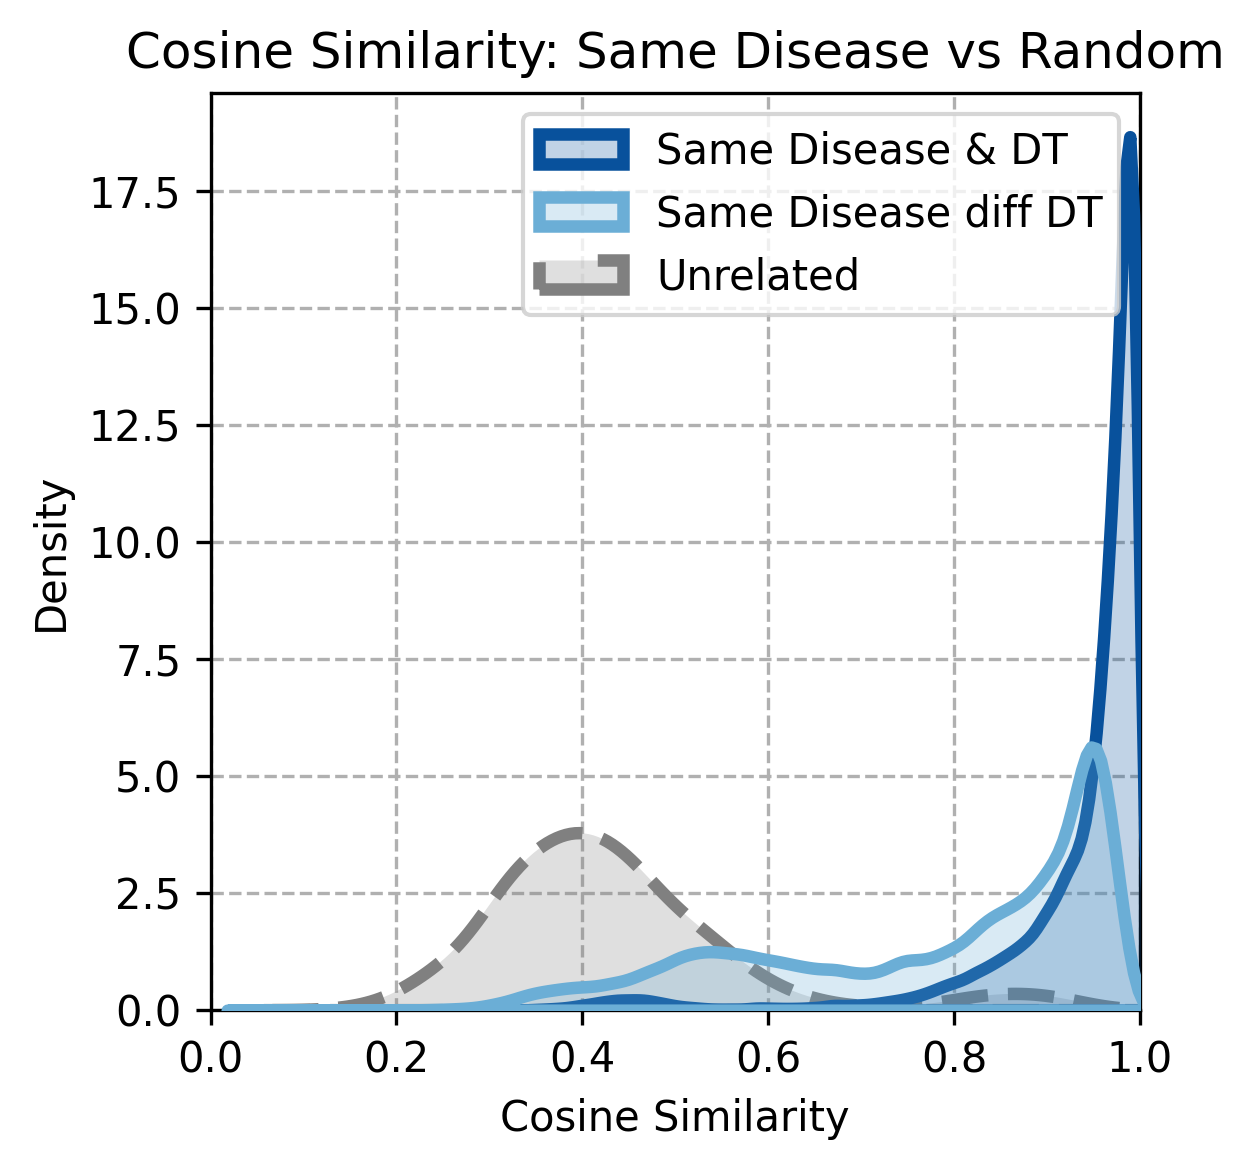

# 3. Benchmark Disease Related Disease Similarity

In [19]:
"""Benchmark Disease Related Disease Similarity

Structure:
    1. Imports, Variables, Functions
    2. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports


# variables


# functions

def plot_kde_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "#2778ff", "#d6f3ff"]  # default palette

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    print(len(unrelated_keys), "unrelated disease pairs")
    do_ids = adata_obs["do_id_study"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        print(f"[SP {sp_val}] Nº of related disease pairs: {len(_df_query)}")

        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related) / len(_c_related)

        sns.kdeplot(
            x=_c_related,
            weights=_w_related,
            label=f"{sp_val} (n={len(_c_related)})",
            fill=True,
            color=colors[i % len(colors)],
            zorder=3,
            linewidth=3,
        )

    # Add shared random baseline
    n_needed = len(_c_related) // 10
    print("n_needed", n_needed)
    print("len(c_relate)", len(_c_related))

    rand_pairs = set()
    while len(rand_pairs) < n_needed:
        a, b = np.random.choice(len(do_ids), 2, replace=False)
        do1, do2 = do_ids[a], do_ids[b]
        if do1 == do2:
            continue
        if tuple(sorted([do1, do2])) in unrelated_keys:
            continue
        rand_pairs.add((a, b))

    rand_pairs = np.array(list(rand_pairs))
    print(len(rand_pairs))
    _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
    sns.kdeplot(_c_rand, label="Unrelated", fill=True, color="gray", linewidth=3,  zorder=2)

    plt.title("Cosine Similarity: Related Diseases")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")

    # plot legend title
    plt.legend(title="DO disease distance")

    plt.tight_layout()
    plt.xlim(0, 1)
    plt.grid(zorder=-3, linestyle="--")
    plt.show()

def plot_roc_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None, weights_bool=True
):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    do_ids = adata_obs["do_id_study"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related)

        # Negative sampling
        rand_pairs = set()
        while len(rand_pairs) < len(_c_related):
            a, b = np.random.choice(len(do_ids), 2, replace=False)
            do1, do2 = do_ids[a], do_ids[b]
            if do1 == do2:
                continue
            if tuple(sorted([do1, do2])) in unrelated_keys:
                continue
            rand_pairs.add((a, b))
        rand_pairs = np.array(list(rand_pairs))
        _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
        _w_rand = np.ones(len(_c_rand))

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_c_rand))])
        scores = np.concatenate([_c_related, _c_rand])
        weights = np.concatenate([_w_related, _w_rand])

        if weights_bool:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{sp_val} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()



In [20]:
do_df_ic_query["lin"].describe()

count    1138.000000
mean        0.496843
std         0.105151
min         0.396108
25%         0.409783
50%         0.452488
75%         0.549432
max         0.956801
Name: lin, dtype: float64

(array([  0.,   0.,   0.,  98., 571., 306.,  92.,  55.,  11.,   5.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

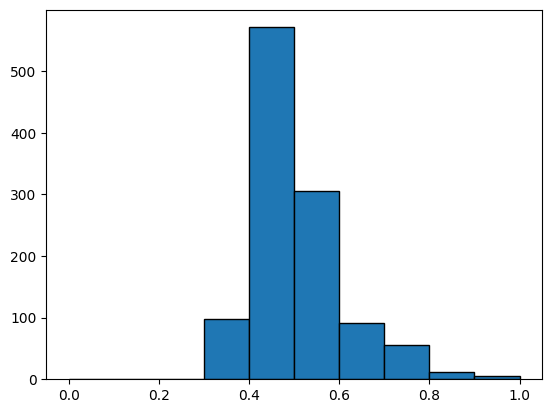

In [21]:
plt.hist(df_query["lin"].values, bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], edgecolor="black")

1138 unrelated disease pairs
[SP '0.8-1'] Nº of related disease pairs: 16
[SP '0.6-0.8'] Nº of related disease pairs: 147
[SP '0.4-0.6'] Nº of related disease pairs: 877
n_needed 392855
len(c_relate) 3928556
392855


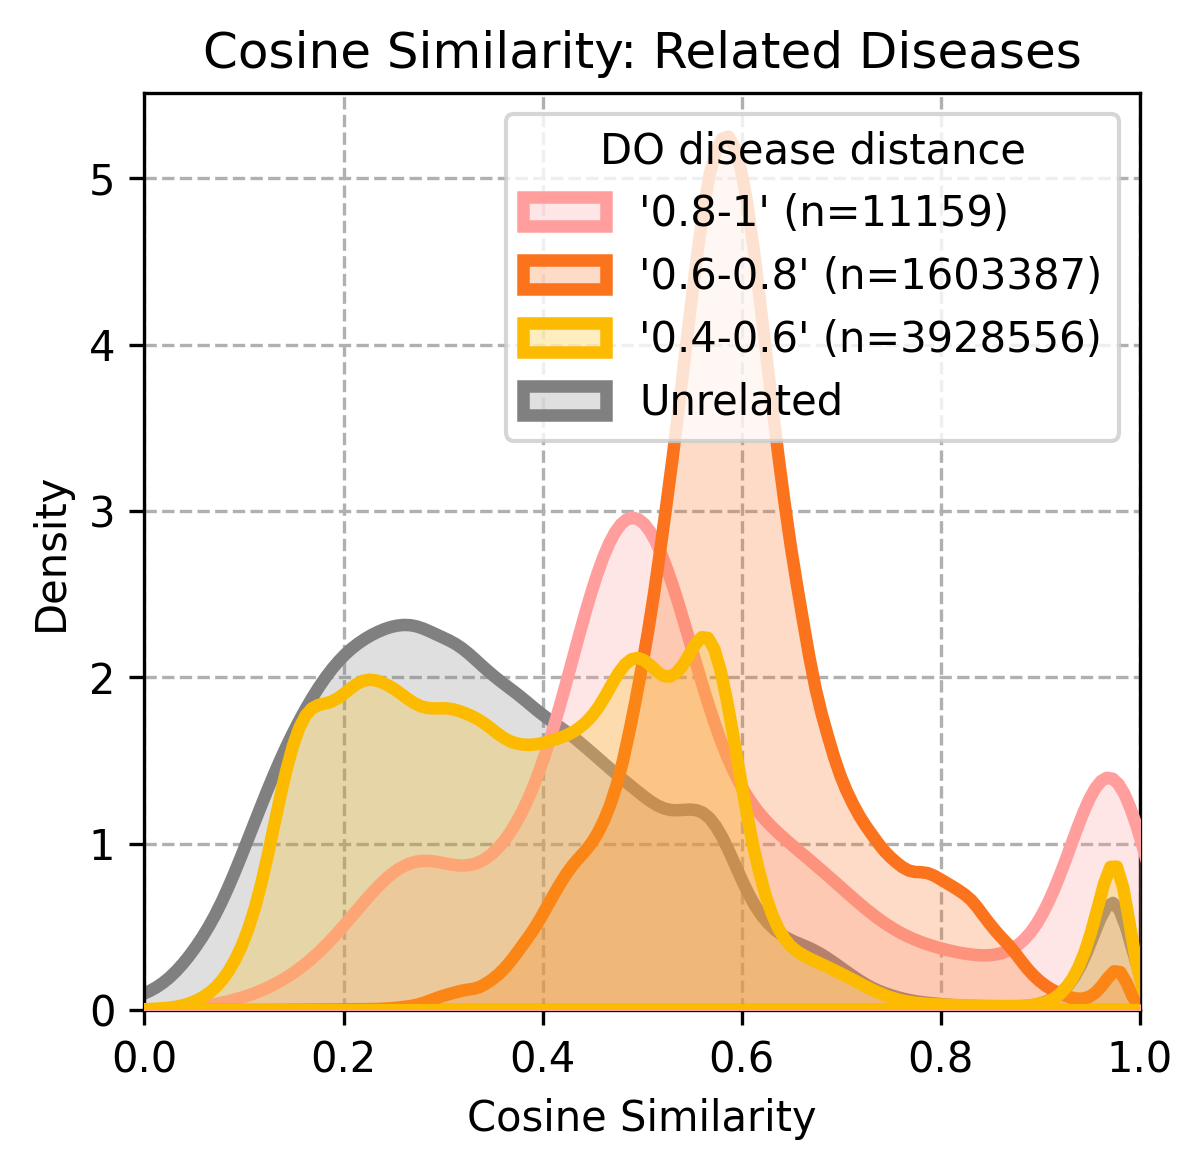

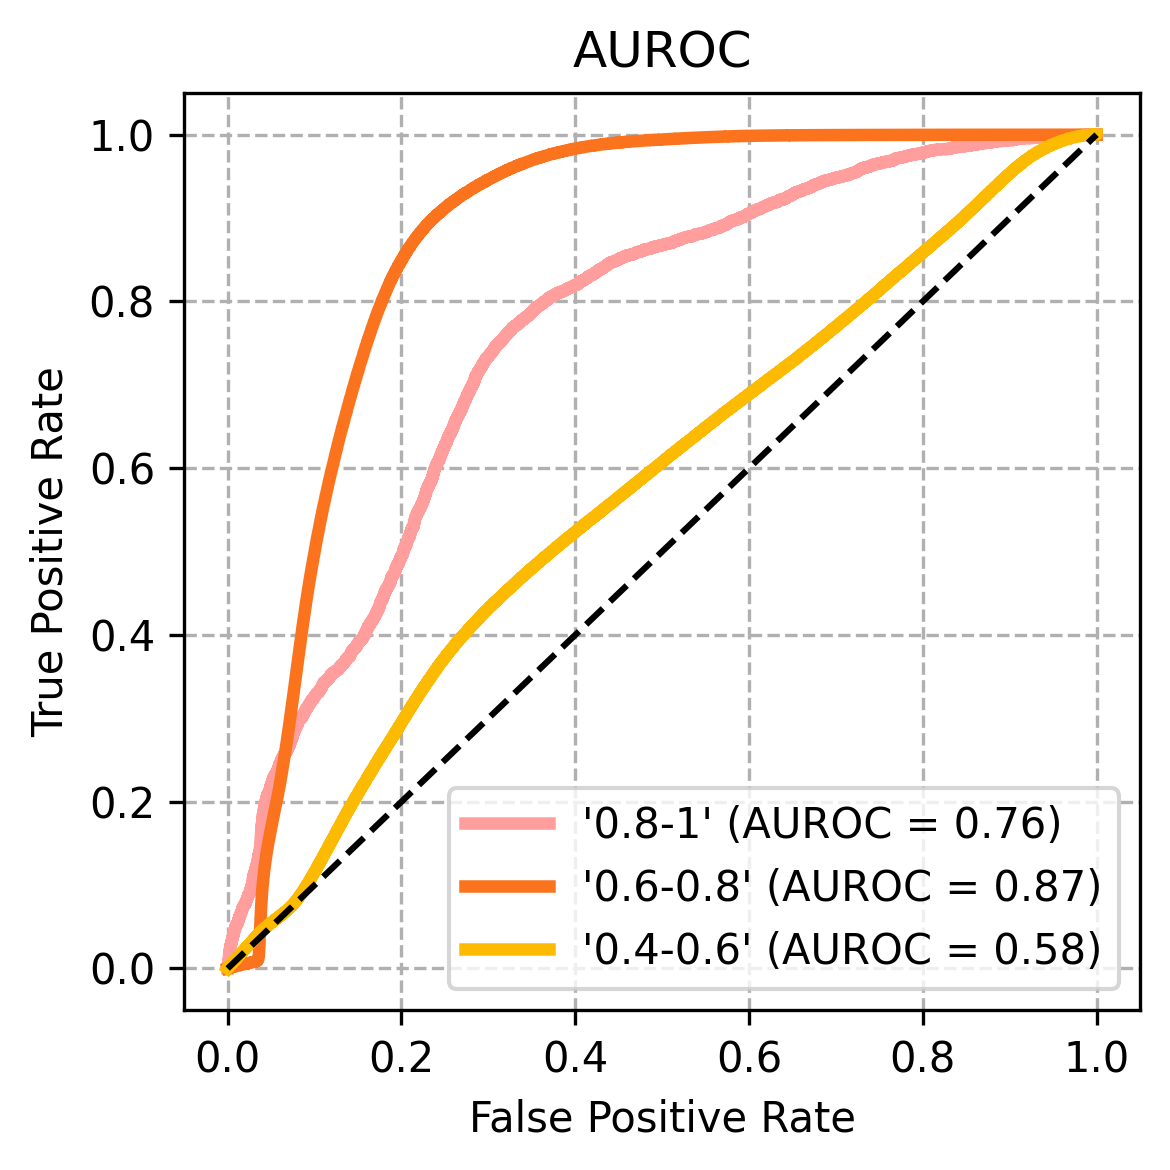

In [22]:
df_query = do_df_ic_query.copy()

def get_bins(vals, bins):
    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list



_bins = get_bins(df_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.4-0.6'","'0.6-0.8'","'0.8-1'",]

# _bins = get_bins(df_query["lin"].values,[0,0.1,0.2, 0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
# _bin_labels = ["'0.4-0.5'","'0.5-0.6'","'0.6-0.7'","'0.7-0.8'","'0.8-0.9'","'0.9-1'",]


df_query = df_query.copy()
df_query["shortest_path_length"] = _bins

df_query["shortest_path_length"].value_counts()

# KDE
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=_bin_labels[::-1],
)


plot_roc_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=_bin_labels[::-1])

1138 unrelated disease pairs
[SP 2] Nº of related disease pairs: 79
[SP 3] Nº of related disease pairs: 137
[SP 5] Nº of related disease pairs: 208
n_needed 167188
len(c_relate) 1671885
167188


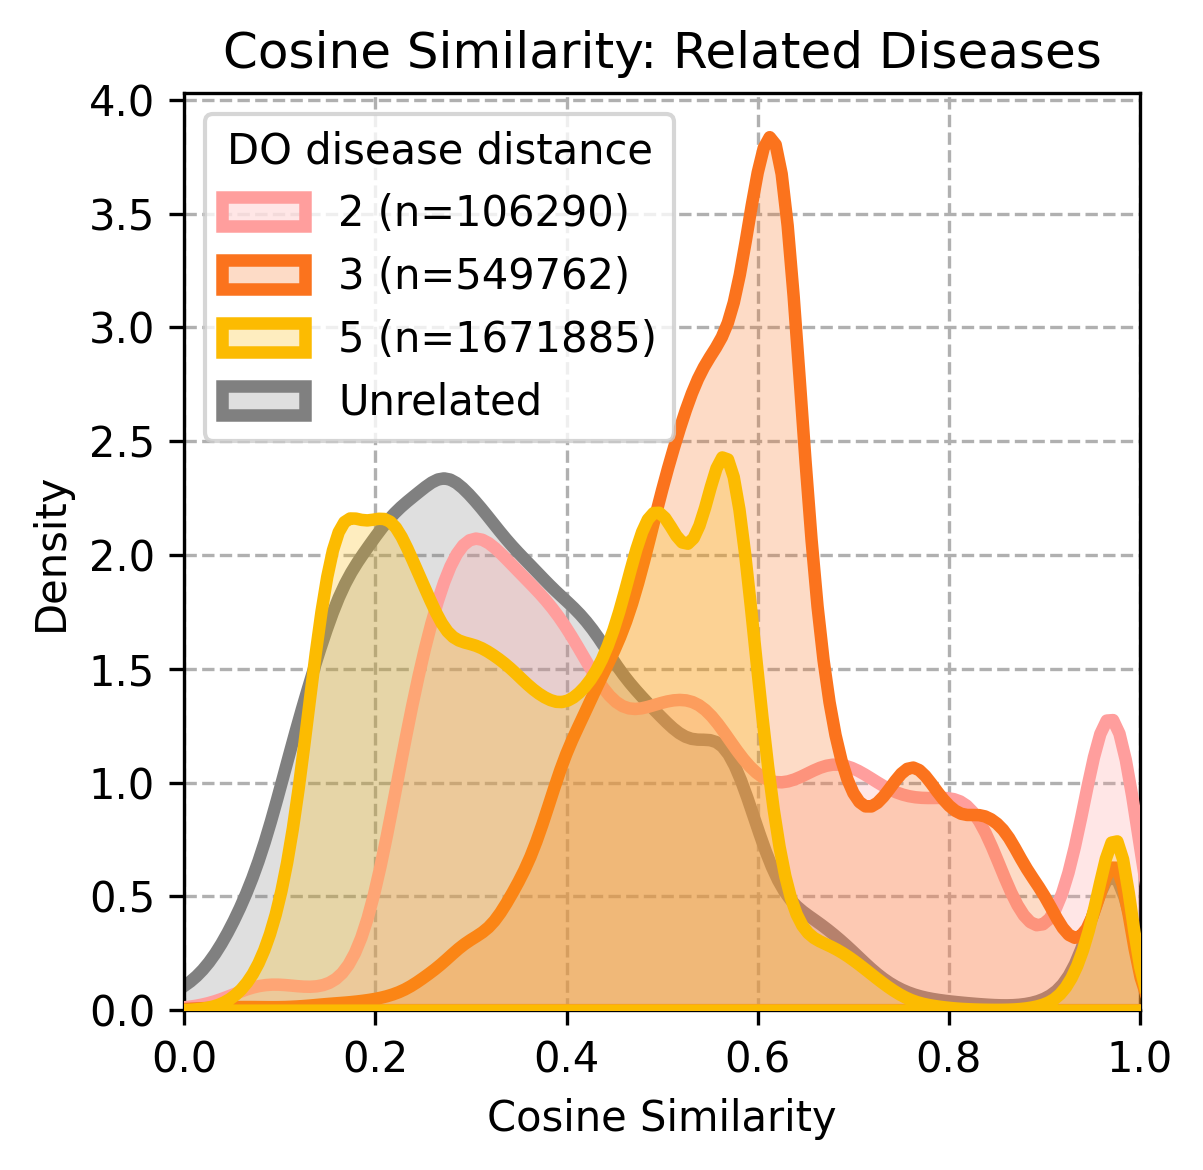

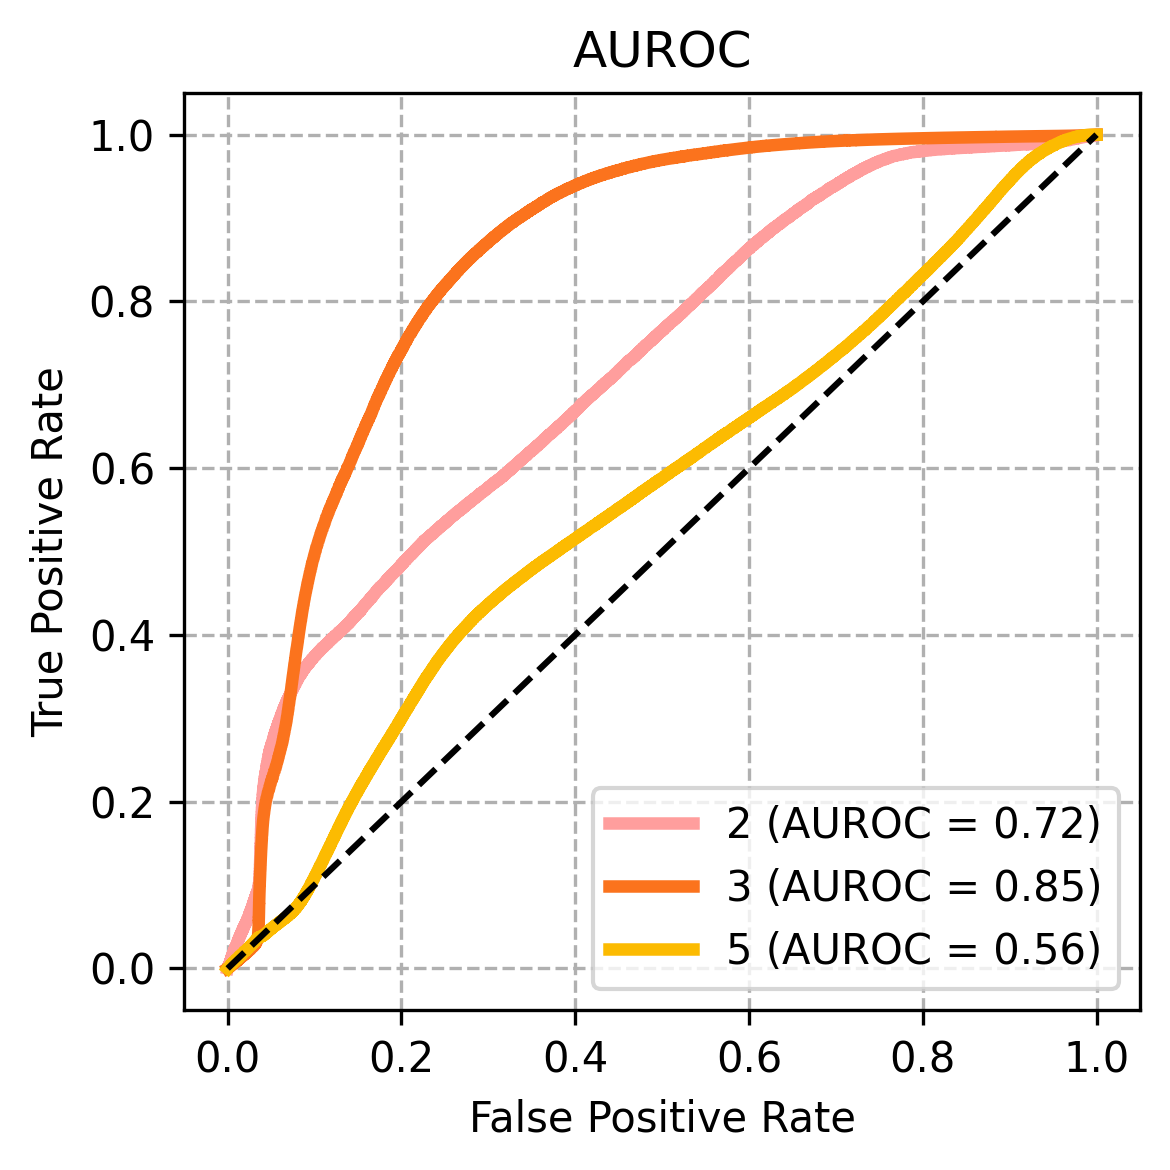

In [23]:
# 2. Plot Similarity
df_query = do_df_ic_query.copy()
# KDE
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5],
)


plot_roc_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5])

1138 unrelated disease pairs
[SP 2] Nº of related disease pairs: 79
[SP 3] Nº of related disease pairs: 137
[SP 5] Nº of related disease pairs: 208
n_needed 167188
len(c_relate) 1671885
167188


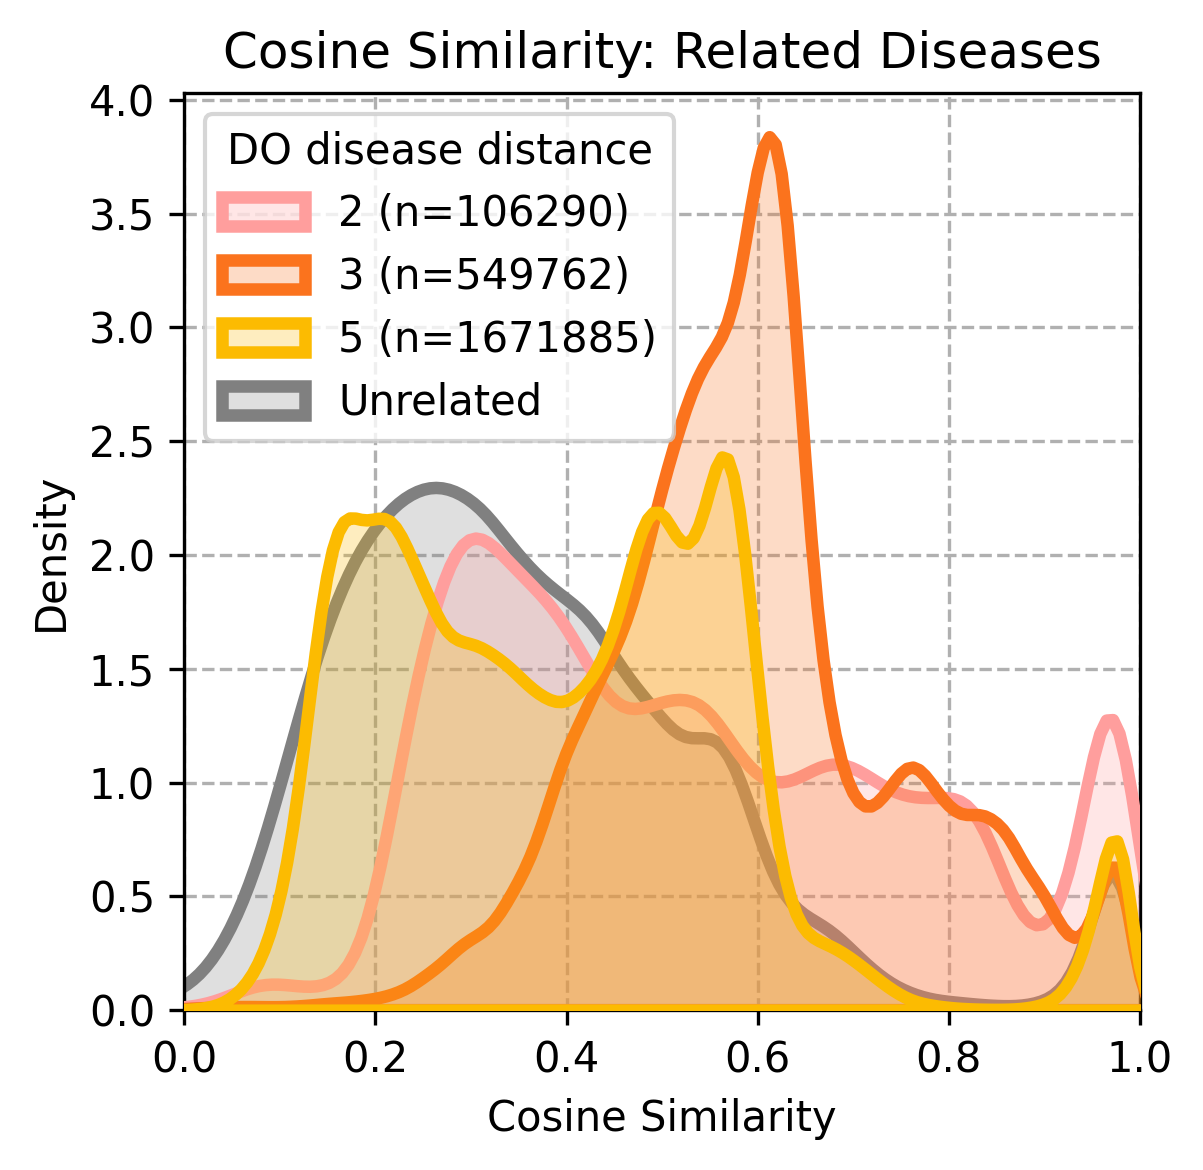

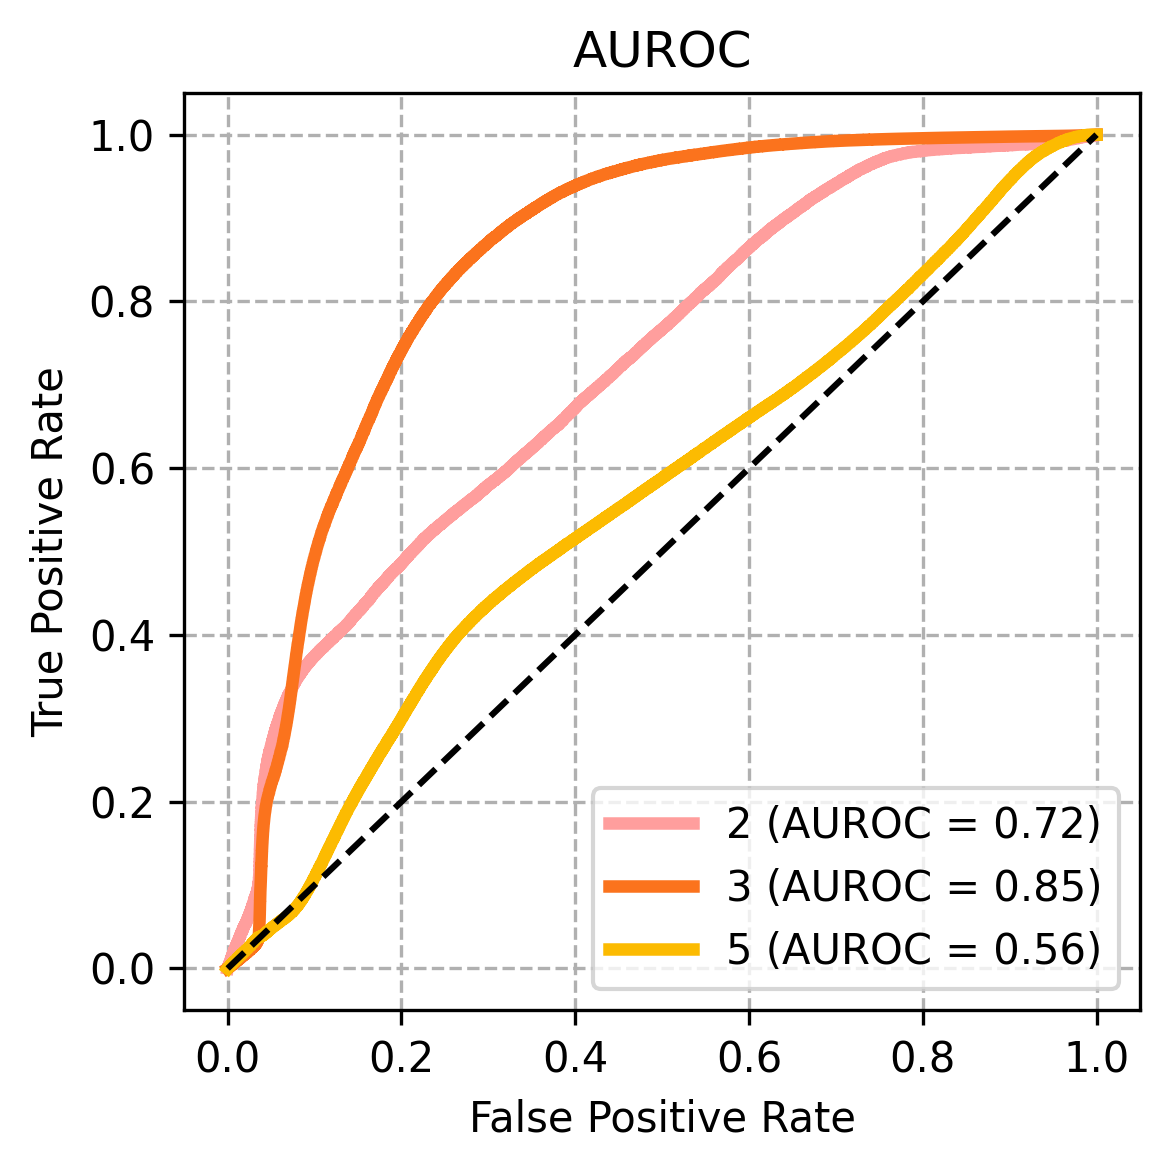

In [24]:
# 2. Plot Similarity
df_query = do_df_ic_query.copy()
# KDE
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5],
)


plot_roc_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5])

330 unrelated disease pairs
[SP 2] Nº of related disease pairs: 50
[SP 3] Nº of related disease pairs: 56
[SP 5] Nº of related disease pairs: 59
n_needed 95385
len(c_relate) 953854
95385


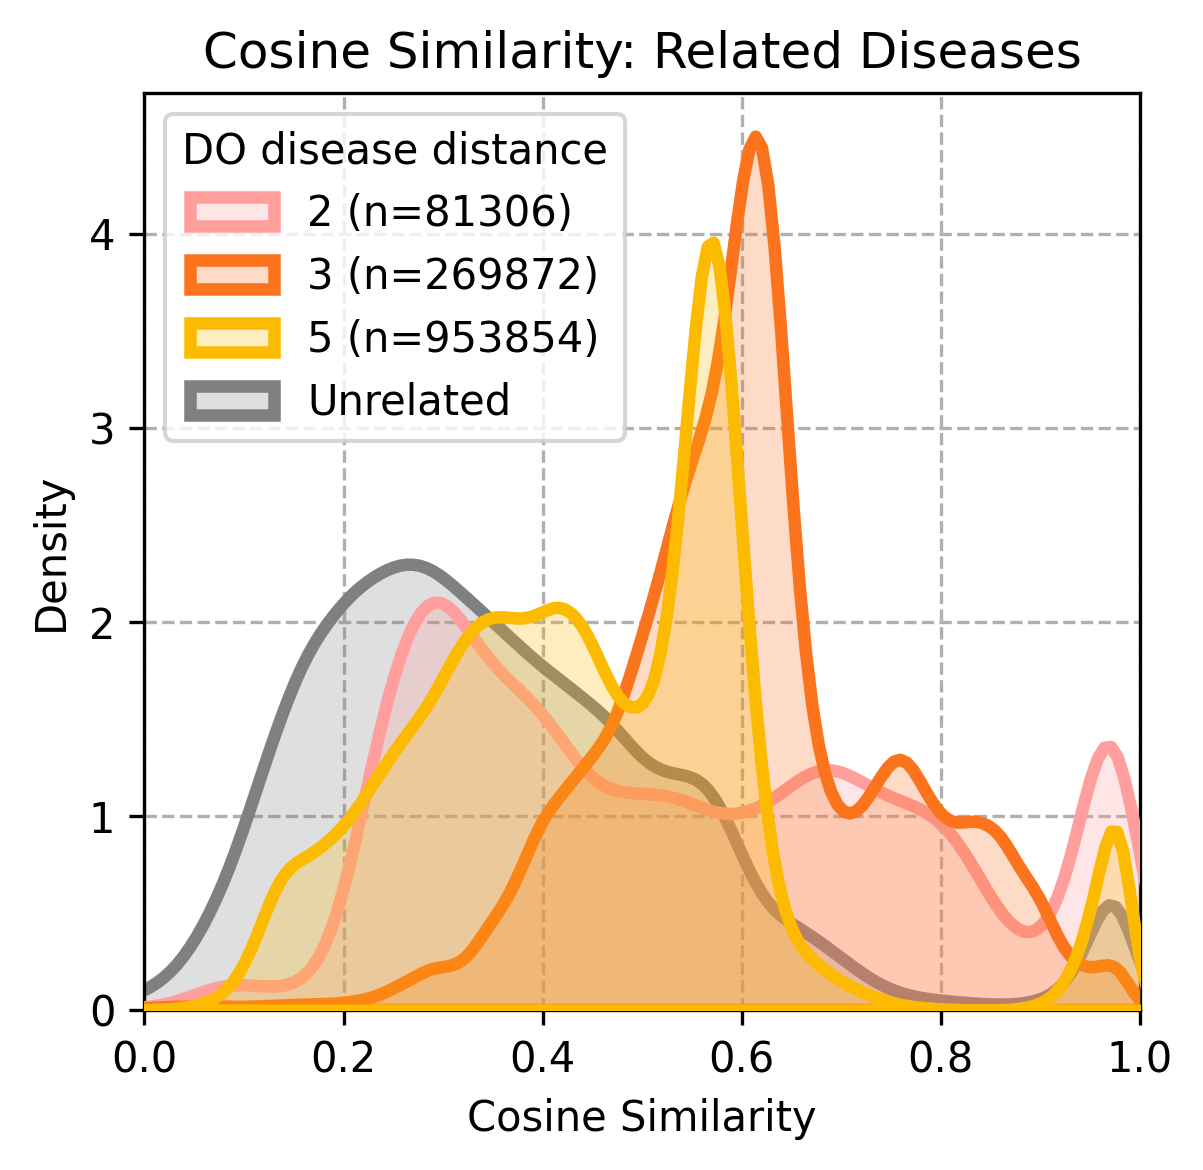

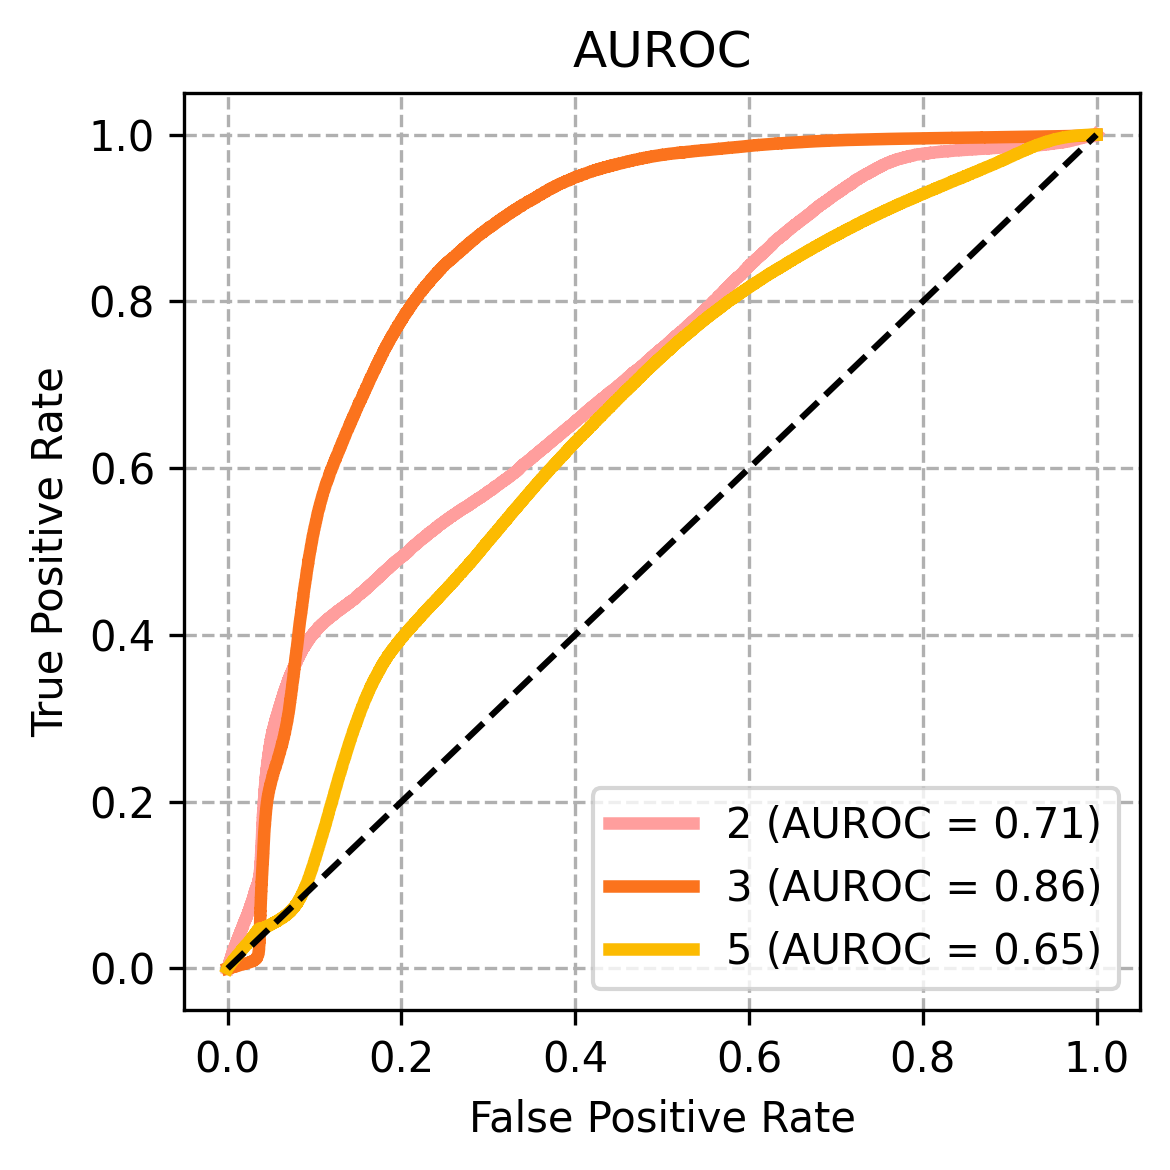

In [25]:
df_query = do_df_ic_query_99.copy()
plot_kde_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5],
)

# ROC
plot_roc_for_shortest_path_relatedness(
    c_matrix_train, adata_train.obs, df_query, s_p=[2, 3, 5])

# 4. tSNE Embeddiding plots

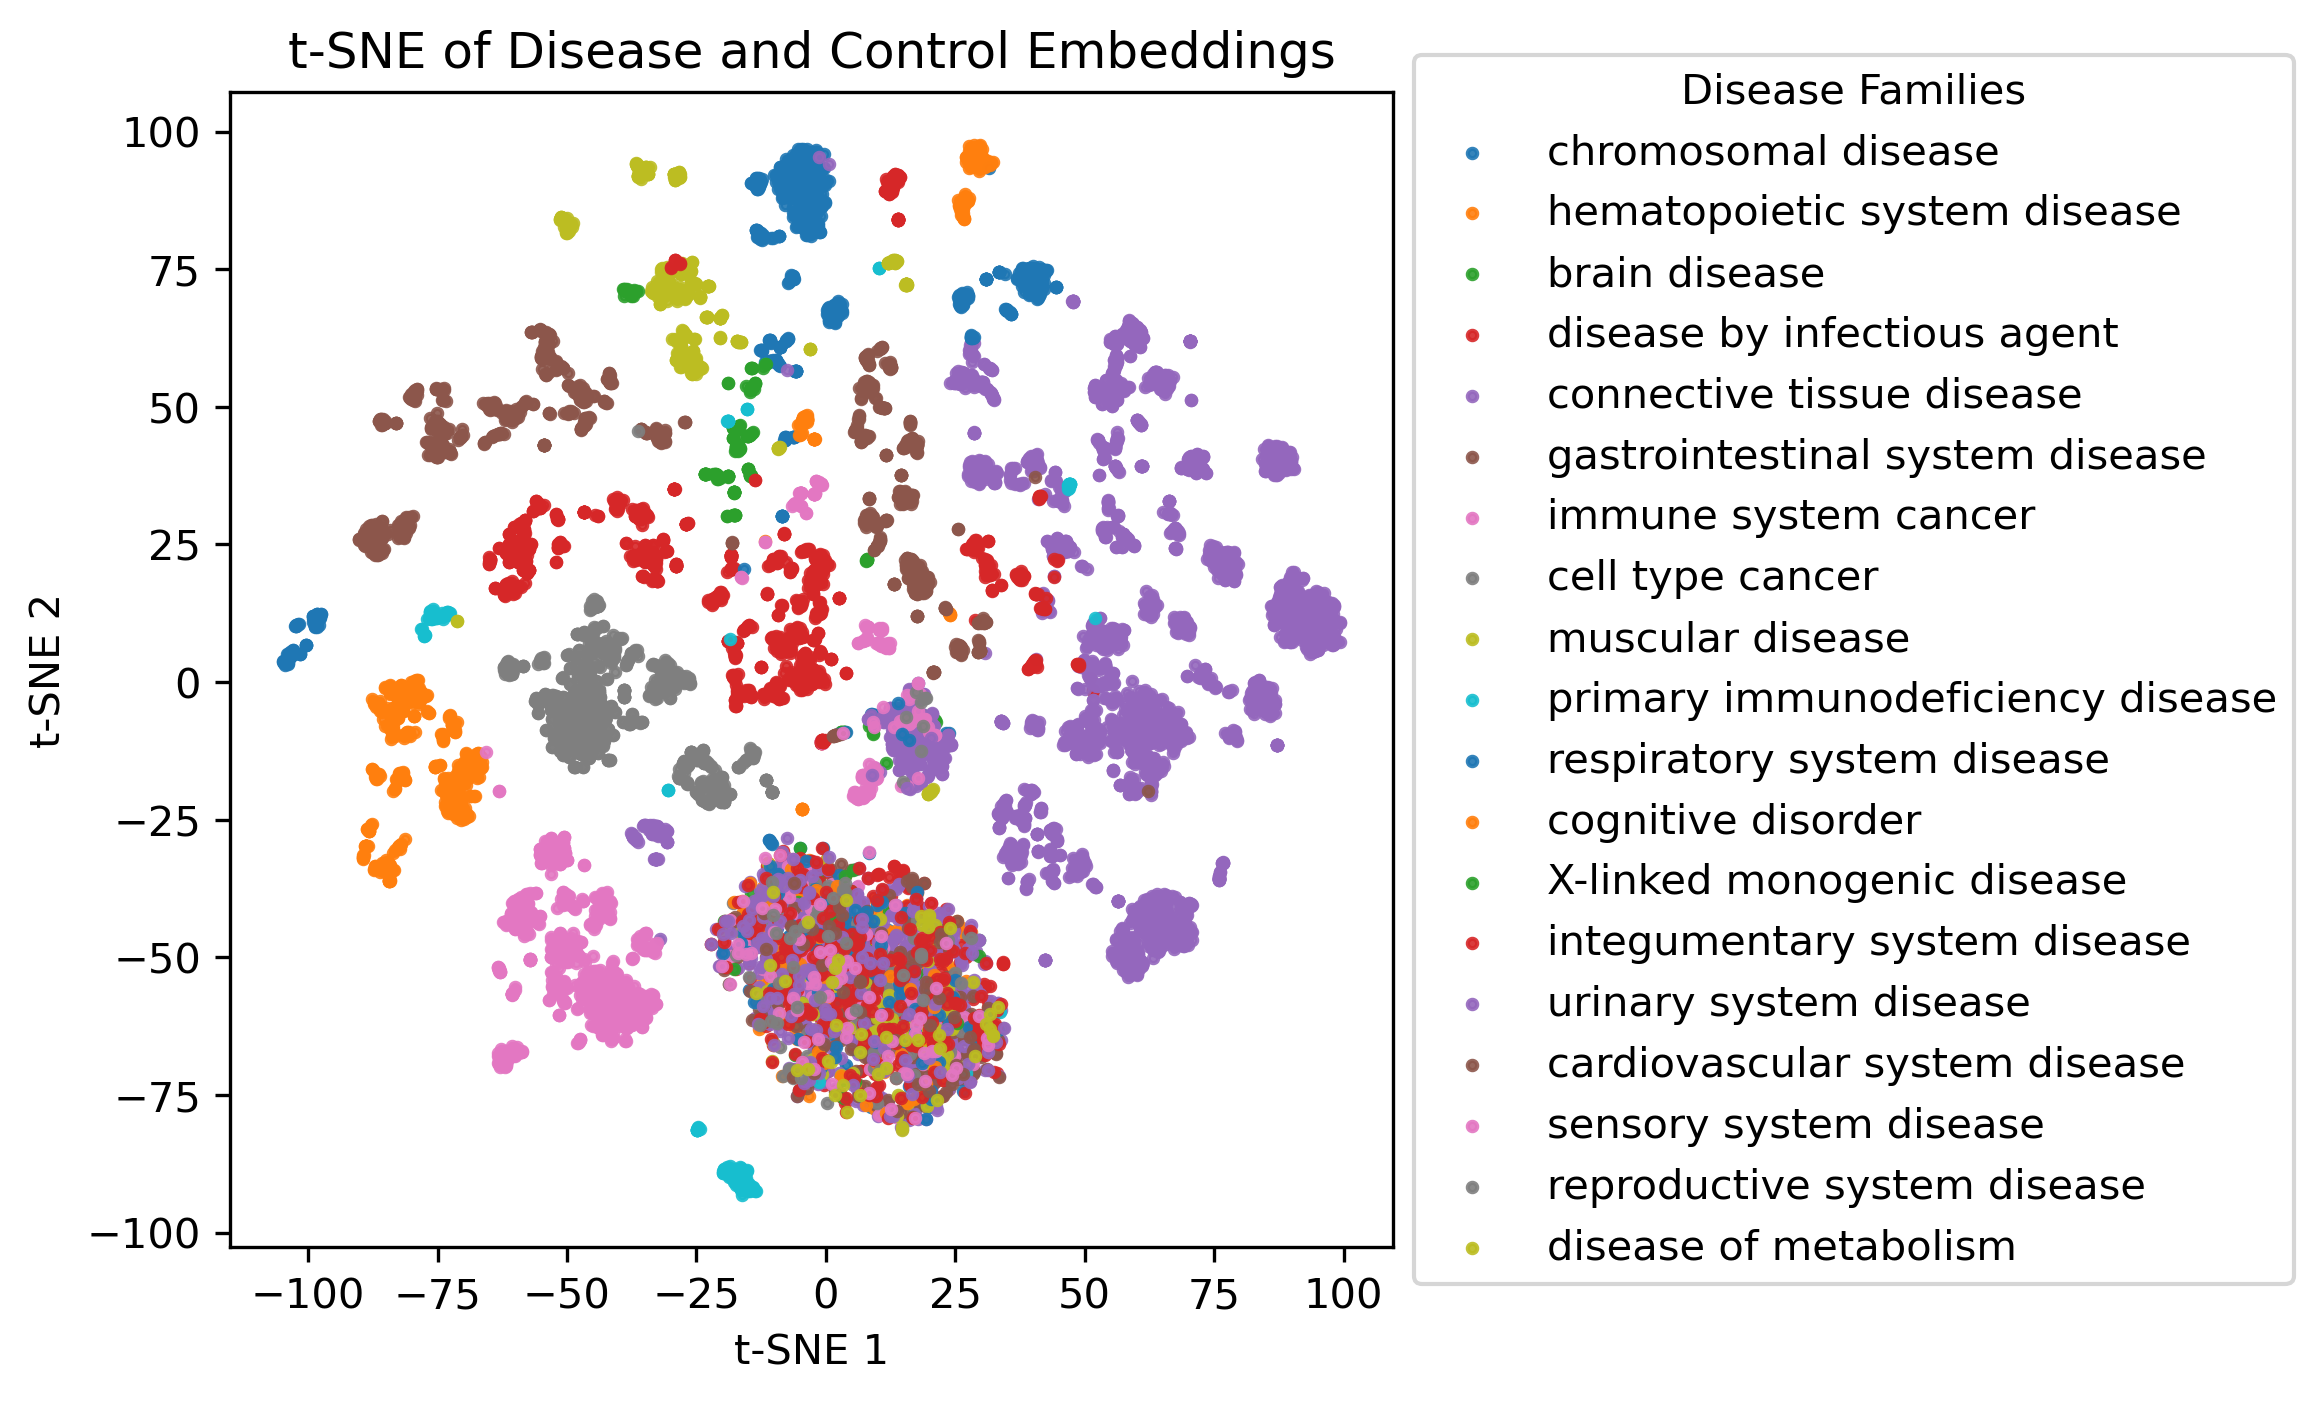

In [22]:
# t-SNE
from sklearn.manifold import TSNE

# Lets color by disease families
_d_masks = list()
for i in adata_train.obs["do_id"].unique():
    _d_masks.append((i, np.array((adata_train.obs["do_id"] == i) & (adata_train.obs["is_control"] == "D"))))

# let's run t-SN
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(embeddings_train)

# scatter plot 
plt.figure(figsize=(5, 5), dpi=300)
for i in range(len(_d_masks)):
    _doid, _d_mask = _d_masks[i]
    plt.scatter(
        X_embedded[_d_mask][:, 0], X_embedded[_d_mask][:, 1], label=doid_to_term.get(_doid), alpha=0.9, s=5
    )
plt.title("t-SNE of Disease and Control Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Disease Families")